# 2주차 실습: 자연어와 텍스트 데이터 이해

**과목:** 자연어처리(NLP)  
**환경:** Google Colab / Python 3  

> **배포용 반완성 노트북**입니다. 안내된 순서대로 실행하고, `TODO`와 **체크포인트**를 직접 완성하세요.

## 오늘의 목표
1. 텍스트 데이터를 표 형태로 불러오고 구조를 점검한다.
2. 문서·문장·토큰 등 텍스트 데이터의 기본 단위를 구분한다.
3. 길이, 빈도, 어휘 다양성 등 기초 탐색적 텍스트 분석을 수행한다.
4. 한글 텍스트와 UTF-8 인코딩·유니코드 정규화 이슈를 확인한다.
5. 분석 전 데이터 품질·개인정보·저작권 관점을 점검한다.

## 실습 원칙
- `TODO`는 직접 작성하고 실행 결과를 남깁니다.
- 숫자와 그래프를 출력하는 것에서 멈추지 않고, **무엇을 의미하는지** 체크포인트에 기록합니다.
- 이 자료의 데이터는 교육용 예시입니다. 실제 데이터를 사용할 때에는 출처·라이선스·개인정보 여부를 먼저 확인합니다.
- 외부 생성형 AI나 자료를 사용했다면 사용 범위와 검증 과정을 README 또는 노트북에 기록합니다.


## 0. 실습 데이터 소개

이번 실습에서는 온라인 영화 리뷰를 축약한 **교육용 예시 데이터**를 사용합니다. 실제 프로젝트에서는 데이터의 출처, 수집일, 이용 조건, 개인정보 포함 여부를 반드시 확인해야 합니다.

In [ ]:
import re # 정규화 모듈
from collections import Counter # 빈도수 세기 위한 Counter 객체
import pandas as pd # 표로 시각화하기 위함(df)

reviews = [
    (1, '정말 재미있어요! 배우들의 연기가 인상적이었습니다.', 1, '2026-08-25'),
    (2, '스토리는 평범하지만 음악이 좋네요.', 1, '2026-08-25'),
    (3, '기대보다 지루했고 결말이 아쉬웠습니다.', 0, '2026-08-26'),
    (4, '영상미는 훌륭합니다. 다만 전개가 조금 느려요.', 1, '2026-08-26'),
    (5, '다시는 보고 싶지 않은 영화예요...', 0, '2026-08-27'),
    (6, '가족과 함께 보기 좋은 따뜻한 작품입니다 :)', 1, '2026-08-27'),
    (7, '배우는 좋았지만 대사가 잘 들리지 않았어요.', 0, '2026-08-28'),
    (8, '추천합니다! 다음 편도 꼭 보고 싶어요.', 1, '2026-08-28'),
    (9, '별로예요. 러닝타임이 너무 길게 느껴집니다.', 0, '2026-08-29'),
    (10, '생각할 거리를 주는 좋은 영화였습니다.', 1, '2026-08-29'),
]

df = pd.DataFrame(reviews, columns=['review_id', 'text', 'label', 'date'])

# TODO 1. label 값(1, 0)을 각각 '긍정', '부정'으로 바꾼 label_name 열을 만드세요.
# 힌트: map()
df['label_name'] = list(map(lambda x: '긍정' if x == 1 else '부정', df['label']))
# 람다함수(lambda)를 활용하면 간단한 연산 함수를 간결하게 구현할 수 있음

df


,review_id,text,label,date,label_name
0,1,정말 재미있어요! 배우들의 연기가 인상적이었습니다.,1,2026-08-25,긍정
1,2,스토리는 평범하지만 음악이 좋네요.,1,2026-08-25,긍정
2,3,기대보다 지루했고 결말이 아쉬웠습니다.,0,2026-08-26,부정
3,4,영상미는 훌륭합니다. 다만 전개가 조금 느려요.,1,2026-08-26,긍정
4,5,다시는 보고 싶지 않은 영화예요...,0,2026-08-27,부정
5,6,가족과 함께 보기 좋은 따뜻한 작품입니다 :),1,2026-08-27,긍정
6,7,배우는 좋았지만 대사가 잘 들리지 않았어요.,0,2026-08-28,부정
7,8,추천합니다! 다음 편도 꼭 보고 싶어요.,1,2026-08-28,긍정
8,9,별로예요. 러닝타임이 너무 길게 느껴집니다.,0,2026-08-29,부정
9,10,생각할 거리를 주는 좋은 영화였습니다.,1,2026-08-29,긍정


## 1. 텍스트 데이터의 기본 단위

- **코퍼스(corpus)**: 분석을 위해 모은 텍스트 전체
- **문서(document)**: 코퍼스를 구성하는 개별 텍스트 (여기서는 리뷰 한 건)
- **문장(sentence)**: 문서 안의 의미 단위
- **토큰(token)**: 분석을 위해 나눈 단위. 단어, 형태소, 서브워드 등이 될 수 있음

같은 문장도 토큰화 규칙에 따라 결과가 달라집니다. 지금은 원리를 이해하기 위해 간단한 정규표현식 토크나이저를 사용합니다.

In [ ]:
sample = df.loc[0, 'text'] #'정말 재미있어요! 배우들의 연기가 인상적이었습니다.'(0번째 text)
print('원문:', sample)
print('공백 기준:', sample.split())

# TODO 2. 한글·영문·숫자로 이루어진 덩어리만 추출하는 정규표현식 토큰화를 완성하세요.
# 힌트: re.findall()
regex_tokens = re.findall(r'[가-힣A-Za-z0-9]+', sample) # 참고: ^가 있으면 제외한다는 것.
# \s 는 공백
# \w 는 문자([가-힣A-Za-z0-9_])
# +는 최소 1번 이상 반복되는 경우

print('간단 정규표현식:', regex_tokens)


원문: 정말 재미있어요! 배우들의 연기가 인상적이었습니다.
공백 기준: ['정말', '재미있어요!', '배우들의', '연기가', '인상적이었습니다.']
간단 정규표현식: ['정말', '재미있어요', '배우들의', '연기가', '인상적이었습니다']


### 체크포인트 1 — 분석 단위

`재미있어요!`가 공백 기준 토큰화와 정규표현식 토큰화에서 어떻게 다른지 설명해 보세요.  
또한 실제 한글 분석에서 형태소 분석기(Kiwi, KoNLPy 등)가 필요한 이유를 한 문장으로 적어 보세요.

- 느낌표 등이 사라집니다.
- 의미의 최소 단위인 어절/토큰으로 분리하기 위해서 형태소 분석기가 필요합니다.

## 2. 데이터 구조와 결측치 점검

분석을 시작하기 전에 행 수, 열의 의미, 자료형, 결측치, 중복을 확인합니다. 이 단계는 모델링보다 앞서 수행해야 합니다.

In [ ]:
print('데이터 크기:', df.shape) # 몇행 몇열인지 표현
print('자료형:')
display(df.dtypes) # 자료가 어떤 자료형으로 구성되어 있는지(display: 표 형태로 보여줌)
print('결측치 수:')
display(df.isna().sum()) # isna: 해당 셀이 결측치라면, True(1)로 변환. sum: (컬럼 기준으로. axis=0) 셀 값을 모두 더함 -> 결측치가 몇개 있는지 보여줌

# TODO 3. text 열에서 중복된 리뷰의 개수를 출력하세요. duplicated()
print('중복 리뷰 수:', df['text'].duplicated().sum()) # duplicated: 원본 df['text']의 행 개수와 똑같은 크기 6의 Boolean Series를 반환. 처음 나오면 False, 중복이면 True.

print('라벨 분포:')
display(df['label_name'].value_counts()) # value_counts: df['label_name']에 들어있는 데이터의 종류별 개수를 카운트.


데이터 크기: (10, 5)
자료형:


,0
review_id,int64
text,object
label,int64
date,object
label_name,object


결측치 수:


,0
review_id,0
text,0
label,0
date,0
label_name,0


중복 리뷰 수: 0
라벨 분포:


,count
label_name,
긍정,6
부정,4


In [ ]:
# @title Colab에서 한글 폰트 설치

!apt-get install -y fonts-nanum # 나눔 폰트 설치
!fc-cache -fv # OS 레벨에서 설치된 폰트 캐시 갱신

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 0 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (3,925 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/humor-sans
	/usr/share/fonts/truetype/liberation
	/usr/share/fonts/tr

In [ ]:
# @title 🇰🇷 matplotlib 한글 깨짐 방지 설정
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path) # matplotlib의 폰트 매니저에 수동으로 폰트 파일 등록.

font_name = fm.FontProperties(fname=font_path).get_name() # 파일 경로에서 폰트 이름을 반환(오타 방지)
print(font_name)  # 'NanumGothic' 이 출력되어야 함

plt.rcParams['font.family'] = font_name # 기본 폰트를 나눔고딕으로 변경
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지


NanumGothic


label_name
긍정    6
부정    4
Name: count, dtype: int64
counts의 타입은 <class 'pandas.core.series.Series'>


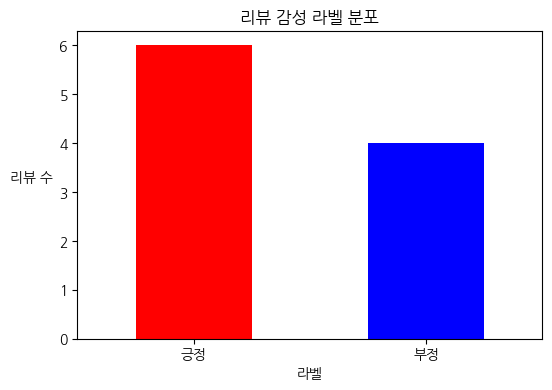

In [ ]:
# 라벨 분포 시각화
counts = df['label_name'].value_counts().reindex(['긍정', '부정']) # value_counts().reindex: 빈도 계산 후, 지정한 인덱스 순서대로 결과 재정렬. 지정한 인덱스가 없는 경우 NaN(결측치)으로 채워넣음.
print(counts)                                                      # 여기서는 의미는 없었음.

print(f"counts의 타입은 {type(counts)}") # series

plt.figure(figsize=(6, 4)) # 차트를 그릴 틀을 생성
# TODO 4. counts를 막대그래프로 시각화하세요.
# 힌트: counts.plot(kind='차트종류' , color=, rot=)
ax = counts.plot(kind='bar', color=['red', 'blue'], rot=0) # rot: x축 눈금 글자가 가로로 정렬되도록.
ax.set_title('리뷰 감성 라벨 분포')
ax.set_xlabel('라벨')
ax.set_ylabel('리뷰 수', rotation=0, labelpad=20) # rotation=0: 90도 돌리기. labelpad=20: 축과 거리 20만큼 벌리기
plt.show()


### 체크포인트 2 — 데이터 구조

1. 이 데이터의 행 하나는 무엇을 의미하나요?
2. `label`과 `label_name`을 함께 두는 이유는 무엇인가요?
3. 현재 라벨 분포가 실제 감성분석 모델 학습용으로 충분히 균형 잡혔다고 볼 수 있는지, 근거와 함께 1~2문장으로 답하세요.


- 1. 리뷰 하나를 의미합니다.
- 2. 저장 및 처리 효율성을 위해 label을, 가독성을 위해 label_name을 둡니다.
- 3. 긍정과 부정의 라벨 분포 비율이 6:4이므로, 충분히 균형 잡혔다고 볼 수 있습니다.

## 3. 텍스트 길이 탐색

텍스트 길이는 매우 짧거나 긴 문서, 빈 문자열, 복제된 안내 문구 등을 찾는 데 도움을 줍니다. 여기서는 문자 수와 공백 기준 어절 수를 모두 살펴봅니다.

In [ ]:
# TODO 5. 문자 수(char_len)와 공백 기준 어절 수(word_len) 열을 생성하세요.
# 힌트: df['text'].str.len()
df['char_len'] = df['text'].str.len() # str: 반복문 없이 Series의 모든 문자열 데이터에 문자열 함수 적용할 수 있게 함(결측치 있으면 NaN으로 유지)
df['word_len'] = df['text'].str.split().str.len() # 여기서는 str.len()이 리스트 안의 원소 개수를 반환

display(df[['review_id', 'label_name', 'char_len', 'word_len', 'text']])

# 아래 표를 보고 긍정/부정 리뷰의 길이를 비교해 보세요.
display(df.groupby('label_name')[['char_len', 'word_len']].agg(['count', 'mean', 'min', 'max']).round(2))
# groupby('label_name')으로 긍정/부정 그룹 나누고, char_len과 word_len을 컬럼으로 선택.
# 선택한 컬럼들에 대해 개수, 평균, 최소, 최대 통계 함수를 동시에 적용. 계산 결과는 소수점 둘째자리까지 반올림합니다.


,review_id,label_name,char_len,word_len,text
0,1,긍정,28,5,정말 재미있어요! 배우들의 연기가 인상적이었습니다.
1,2,긍정,19,4,스토리는 평범하지만 음악이 좋네요.
2,3,부정,21,4,기대보다 지루했고 결말이 아쉬웠습니다.
3,4,긍정,26,6,영상미는 훌륭합니다. 다만 전개가 조금 느려요.
4,5,부정,20,5,다시는 보고 싶지 않은 영화예요...
5,6,긍정,25,7,가족과 함께 보기 좋은 따뜻한 작품입니다 :)
6,7,부정,24,6,배우는 좋았지만 대사가 잘 들리지 않았어요.
7,8,긍정,22,6,추천합니다! 다음 편도 꼭 보고 싶어요.
8,9,부정,24,5,별로예요. 러닝타임이 너무 길게 느껴집니다.
9,10,긍정,21,5,생각할 거리를 주는 좋은 영화였습니다.


char_len                word_len             
              count   mean min max    count mean min max
label_name                                              
긍정                6  23.50  19  28        6  5.5   4   7
부정                4  22.25  20  24        4  5.0   4   6

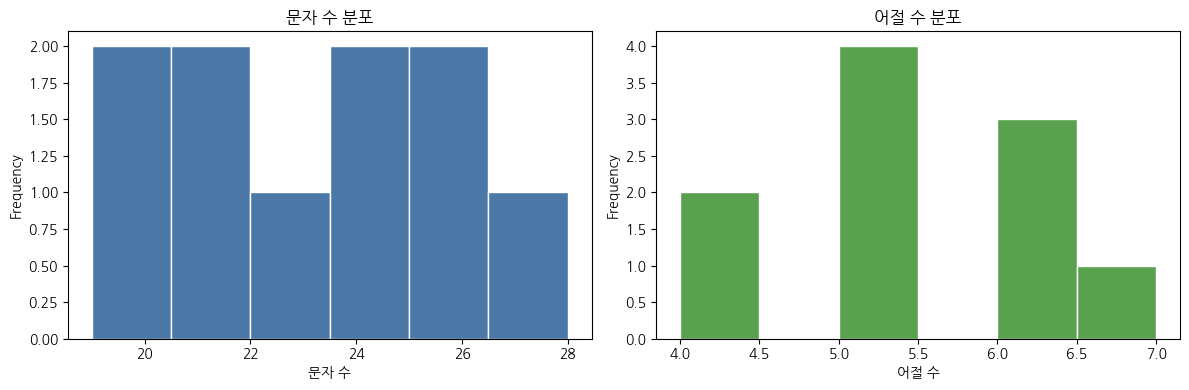

In [ ]:
# 길이 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) # 1행 2열로 그림 넣을 수 있는 틀

# TODO 6. char_len 열의 히스토그램을 왼쪽 그래프에 그리세요.
# 힌트: color='#4C78A8', edgecolor='white'
df['char_len'].plot(kind='hist', bins=6, ax=axes[0], color="#4C78A8", edgecolor='white') # bins=6: 가로축 구간 6개. ax=axes[0]: 왼쪽에서 첫번째 칸에 배치
axes[0].set_title('문자 수 분포')
axes[0].set_xlabel('문자 수')

# 아래 코드는 실행해 어절 수 분포와 비교하세요.
df['word_len'].plot(kind='hist', bins=6, ax=axes[1], color='#59A14F', edgecolor='white')
axes[1].set_title('어절 수 분포')
axes[1].set_xlabel('어절 수')

plt.tight_layout() # 그래프 그릴 때 여러 서브플롯이나 축의 라벨, 제목이 서로 안 겹치게 여백을 자동 조정
plt.show()


### 체크포인트 3 — 길이 탐색

가장 짧은 리뷰와 가장 긴 리뷰를 찾아보세요. 단순히 길다는 사실만으로 오류라고 판단할 수 없는 이유와, 실제 데이터에서 추가 확인할 항목을 한 가지씩 작성하세요.


- '스토리는 평범하지만 음악이 좋네요.'가 19자로 가장 짧았고, '정말 재미있어요! 배우들의 연기가 인상적이었습니다.'가 28자로 가장 길었습니다.
- 19자 대비 상대적으로 긴 28자의 리뷰가 정상 데이터인 것처럼, 문장의 길이 자체는 자연스러운 언어 표현의 결과일 수 있습니다. 따라서 단순 길이 필터링 대신, 의미 없는 문자나 단어의 반복 여부 등을 통해 노이즈를 판별해야 합니다.

## 4. 간단한 토큰 빈도와 어휘 다양성

빈도 분석은 코퍼스의 주제와 노이즈를 빠르게 파악하는 출발점입니다. 다만 조사·어미·불용어가 상위에 나타날 수 있으므로, 결과를 그대로 의미 있는 키워드라고 단정하면 안 됩니다.

In [ ]:
def simple_tokenize(text):
    """한글/영문/숫자 덩어리를 추출하는 매우 단순한 교육용 토크나이저"""
    return re.findall(r'[가-힣A-Za-z0-9]+', text.lower()) # 정규화(한글/영문/숫자 덩어리만 추출 + 소문자 통일)

# TODO 7. 모든 리뷰에서 토큰을 모아 all_tokens 리스트를 만드세요.
# 힌트: [token for text in df['text'] for token in simple_tokenize(text)]

# sol1. 리스트 컴프리헨션을 쓰되, 줄바꿈을 통해 가독성 개선
all_tokens = [
    token
    for text in df['text']
    for token in simple_tokenize(text)
]

# # sol2. pandas의 내장 기능 활용
# df['tokens'] = df['text'].apply(simple_tokenize) # 모든 문장(각 행의 text)을 단어 list로 바꿈
#                                                 # .apply: simple_tokenize를 시리즈의 각 요소에 일괄 적용한 새로운 시리즈 반환
# all_tokens = df['tokens'].explode().tolist() # 각 행에 list로 묶여 있는 단어들을 개별 행으로 풀어주고, series.tolist()를 통해 데이터 값들을 list로 변환
#                                             # .explode: 리스트, 튜플, 집합 등 여러 개의 값이 들어 있는 셀을 각 요소별로 개별 행으로 풀어줌
#                                             # .tolist: series에 포함된 데이터 값들을 list로 변환
# # sol3. for문 이용
# all_tokens = []

# for text in df['text']:
#   tokens = simple_tokenize(text)

#   for token in tokens:
#     all_tokens.append(token)

freq = Counter(all_tokens) # 토큰별 빈도수를 셈

print(type(freq))

print('전체 토큰 수:', len(all_tokens))
print('고유 토큰 수:', len(freq)) # 중복되지 않은 토큰은 몇개인지
print('어휘 다양성(type-token ratio):', round(len(freq) / len(all_tokens), 3)) # 전체 토큰 수 중 고유 토큰 수. 소수점 셋째 자리까지 표현(넷째 자리에서 반올림)
display(pd.DataFrame(freq.most_common(15), columns=['token', 'count'])) # 표로 나타냄
                                                                        # freq.most_common(15): freq에서 빈도수 기준으로 상위 15개의 (요소, 빈도수) 튜플 리스트를 반환
                                                                        # 컬럼 이름은 token, count로 설정


<class 'collections.Counter'>
전체 토큰 수: 52
고유 토큰 수: 50
어휘 다양성(type-token ratio): 0.962


,token,count
0,보고,2
1,좋은,2
2,정말,1
3,재미있어요,1
4,배우들의,1
5,연기가,1
6,인상적이었습니다,1
7,스토리는,1
8,평범하지만,1
9,음악이,1


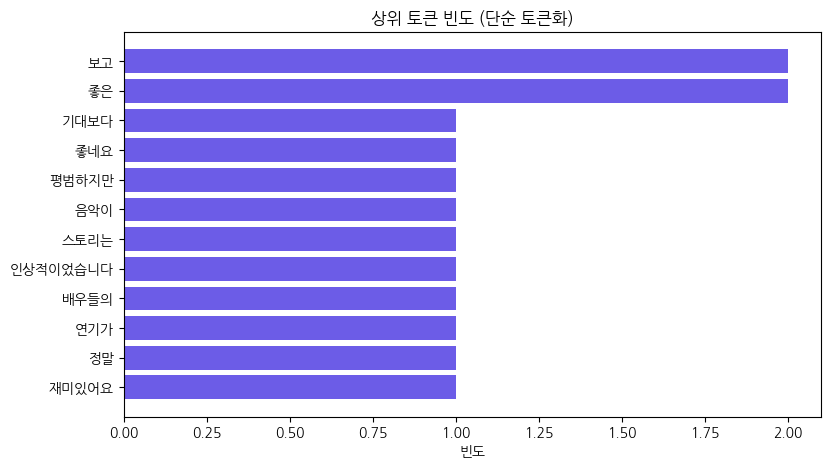

In [ ]:
# 상위 토큰 시각화
# TODO 8. freq의 상위 12개 토큰으로 token, count 열을 가진 데이터프레임을 만드세요.
# 힌트: pd.DataFrame(freq.most_common(12), columns=['token', 'count'])
freq_df = pd.DataFrame(freq.most_common(12), columns=['token', 'count'])
freq_df = freq_df.sort_values('count') # dataframe.sort_values: 특정 열 값 기준으로 데이터를 정렬(여기서는 count)
                                      # 여기서는 df를 만들 때 freq.most_common(12)를 이용하여 이미 정렬된 상태. 따라서 굳이 필요 없음.

plt.figure(figsize=(9, 5))
plt.barh(freq_df['token'], freq_df['count'], color='#6C5CE7') # barh: horizontal bar 만드는 함수. y축으로 토큰을 써주고, 값은 해당 토큰의 빈도수로 설정.
plt.title('상위 토큰 빈도 (단순 토큰화)')
plt.xlabel('빈도')
plt.show()


### 체크포인트 4 - 빈도와 어휘 다양성
상위 빈도 토큰 중 **감성 판단에 직접 도움이 되지 않을 수 있는 토큰**을 찾아 보세요. 이를 처리할 때 생길 수 있는 장점과 단점을 각각 한 가지씩 적어 보세요.

- '보고'는 상위 빈도 토큰 중 하나이지만, 감성 판단에는 직접 도움이 되지 않을 수 있습니다.
- 해당 토큰을 처리, 즉 제거 및 정제를 하면 시각화할 때 감정을 나타내는 실질적인 단어들이 상위에 노출되어 분석 결과를 사람이 이해하기 훨씬 쉬워집니다.
- 하지만 문맥이 소실될 수 있고, 조사나 어미 등을 제거하면 문장의 구조가 무너져 감정의 주체와 객체를 구분할 수 없게 됩니다.

## 5. 한글 텍스트와 인코딩 확인

컴퓨터는 문자를 코드로 저장합니다. UTF-8은 가장 널리 쓰이는 문자 인코딩 중 하나이며, 한글을 포함한 다양한 문자를 표현할 수 있습니다. 파일을 잘못된 인코딩으로 읽으면 `�`처럼 깨진 문자가 나타날 수 있습니다.

또한 겉보기에는 같은 글자라도 유니코드 정규화 방식에 따라 내부 코드가 다를 수 있습니다. 데이터 병합·중복 제거 전에 확인할 가치가 있습니다.

In [ ]:
import unicodedata # 유니코드 정규화(normalize. 내부 유니코드 표현 방식을 일관되게 맞춤)할 때 사용하는 라이브러리

text = '한글 NLP'
print('원문:', text)
print('UTF-8 바이트:', text.encode('utf-8')) # 유니코드 문자열을, 지정된 인코딩 방식의 바이트 열로 변환
                                            # b'\xed\x95\x9c\xea\xb8\x80 NLP'

# TODO 9. UTF-8 바이트를 다시 문자열로 복원하세요.
restored = text.encode('utf-8').decode('utf-8') # 바이트 객체를, 인코딩 방식을 사용하여 문자열로 변환
print('UTF-8로 복원:', restored) # 한글 NLP

# 유니코드 정규화 예시
composed = '가'
decomposed = unicodedata.normalize('NFD', composed) # 정규화 형식을 NFD 타입으로 바꿈
print('겉보기 문자열:', composed, decomposed) # 동일(True)
print('문자열 동일 여부:', composed == decomposed) # 하지만 실제 값은 다르다(False)

print(type(composed))
print(type(decomposed))

print('composed 바이트:', composed.encode('utf-8'))
print('decomposed 바이트:', decomposed.encode('utf-8'))

# TODO 10. 두 문자열을 NFC로 정규화한 뒤 동일한지 확인하세요.
print('NFC 정규화 후 동일 여부:', composed == unicodedata.normalize('NFC', decomposed)) # normalize를 통해 같은 문자인데 바이트 값이 달라지는 것을 방지할 수 있다


원문: 한글 NLP
UTF-8 바이트: b'\xed\x95\x9c\xea\xb8\x80 NLP'
UTF-8로 복원: 한글 NLP
겉보기 문자열: 가 가
문자열 동일 여부: False
<class 'str'>
<class 'str'>
composed 바이트: b'\xea\xb0\x80'
decomposed 바이트: b'\xe1\x84\x80\xe1\x85\xa1'
NFC 정규화 후 동일 여부: True


In [ ]:
# 간단한 품질 점검 함수: 빈 텍스트, 깨진 문자, URL/이메일/전화번호처럼 보이는 패턴을 표시
# ※ 실제 개인정보 탐지는 더 엄격한 정책과 검토가 필요합니다.
def quality_flags(text): # 형식 감지
    flags = []
    if not isinstance(text, str) or not text.strip(): # text가 str이 아니거나, 비었거나 공백만 있다면
        flags.append('빈 텍스트')
    if '�' in text: # 원문이 소실되었을 때 나타나는 유니코드 대체 문자(문자 깨짐)
        flags.append('인코딩 깨짐 의심')
    if re.search(r'https?://\S+|www\.\S+', text): # ?는 s가 있을 수도 없을 수도 있음을 의미(http/https). \S+는 공백이 아닌 연속된 문자 찾음.
        flags.append('URL 포함')                  # 혹은(|) www.으로 시작하고 공백 아닌 연속된 문자 찾음. 결국 http/https 링크나 www 링크가 하나라도 있으면 참.
    if re.search(r'[\w.+-]+@[\w-]+\.[\w.-]+', text): # 문자, 숫자, 밑줄(\w)과 . + - 문자가 1개 이상 반복되고, @가 있고
        flags.append('이메일 포함 가능성')           # 도메인이름 . 최상위도메인 이 있는 경우
    # TODO 11. 전화번호로 보이는 패턴을 탐지하는 정규표현식을 완성하세요.
    # 힌트: r'\d{2,3}[- ]?\d{3,4}[- ]?\d{4}'
    if re.search(r'\d{2,3}[- ]?\d{3,4}[- ]?\d{4}', text): # \d는 [0-9]와 동일. 맨 앞은 2자리 또는 3자리(02/043). 중간은 3자리 또는 4자리(231/1234). 대시는 있을 수도 있고 없을 수도 있음.
        flags.append('전화번호 포함 가능성')
    return ', '.join(flags) if flags else '이상 없음'

df['quality_check'] = df['text'].apply(quality_flags) # df['text']의 각 행에 대해서 quality_flags를 일괄 적용한 새로운 시리즈를 반환
display(df[['review_id', 'text', 'quality_check']])


,review_id,text,quality_check
0,1,정말 재미있어요! 배우들의 연기가 인상적이었습니다.,이상 없음
1,2,스토리는 평범하지만 음악이 좋네요.,이상 없음
2,3,기대보다 지루했고 결말이 아쉬웠습니다.,이상 없음
3,4,영상미는 훌륭합니다. 다만 전개가 조금 느려요.,이상 없음
4,5,다시는 보고 싶지 않은 영화예요...,이상 없음
5,6,가족과 함께 보기 좋은 따뜻한 작품입니다 :),이상 없음
6,7,배우는 좋았지만 대사가 잘 들리지 않았어요.,이상 없음
7,8,추천합니다! 다음 편도 꼭 보고 싶어요.,이상 없음
8,9,별로예요. 러닝타임이 너무 길게 느껴집니다.,이상 없음
9,10,생각할 거리를 주는 좋은 영화였습니다.,이상 없음


### 체크포인트 5 — 인코딩·품질·윤리

UTF-8 인코딩 또는 NFC 정규화를 통일하지 않으면 중복 제거·검색·모델 입력에서 어떤 문제가 생길 수 있나요? 또한 URL·이메일·전화번호를 탐지하는 이유를 개인정보 관점에서 설명하세요.


- UTF-8 인코딩이나 NFC 정규화를 통일하지 않으면, 대체 문자나 자소 분리 현상이 나타나 중복 제거나 검색, 모델 입력이 제대로 이뤄지지 않습니다.
- URL·이메일·전화번호를 탐지하는 이유는, 이들이 개인정보이기 때문입니다. 개인정보는 유출될 경우 범죄 악용과 권리 침해가 발생할 수 있기 때문에, 데이터셋에 포함되지 않도록 보호해야 합니다.

## 6. 미니 실습: 감성별 자주 등장하는 토큰 비교

아래 분석은 **매우 단순한 탐색**입니다. 리뷰 수가 적고, 형태소 분석·불용어 처리·부정 표현 처리도 하지 않았습니다. 따라서 인과관계나 일반적 성능을 주장할 수 없습니다.

- 같은 내용이어도 정규화에 따라 달라질 수 있습니다.

In [ ]:
def top_tokens_by_label(data, label, n=10):
    texts = data.loc[data['label'] == label, 'text'] # label이 인자의 label과 동일한 행들에 대해 text 값을 모아 새로운 시리즈 만듦.
    tokens = [
        tok
        for text in texts
        for tok in simple_tokenize(text) # 특수문자 제거 후 공백 기준으로 분리
    ] # 분리한 tok을 모두 tokens 리스트에 넣음.
    return pd.DataFrame(Counter(tokens).most_common(n), columns=['token', 'count']) # 빈도수 기준 상위 n개의 (토큰, 빈도수) 튜플 리스트 생성해서 데이터프레임 만듦.

# TODO 12. 긍정(1)과 부정(0) 리뷰의 상위 토큰을 각각 구하세요.
positive_top = top_tokens_by_label(df, 1)
negative_top = top_tokens_by_label(df, 0)

print('긍정 리뷰 상위 토큰')
display(positive_top)
print('부정 리뷰 상위 토큰')
display(negative_top)


긍정 리뷰 상위 토큰


,token,count
0,좋은,2
1,정말,1
2,재미있어요,1
3,배우들의,1
4,연기가,1
5,인상적이었습니다,1
6,스토리는,1
7,평범하지만,1
8,음악이,1
9,좋네요,1


부정 리뷰 상위 토큰


,token,count
0,기대보다,1
1,지루했고,1
2,결말이,1
3,아쉬웠습니다,1
4,다시는,1
5,보고,1
6,싶지,1
7,않은,1
8,영화예요,1
9,배우는,1


### 체크포인트 6 — 결과 해석의 한계

긍정·부정 상위 토큰을 비교해 관찰한 점을 2문장 이내로 적으세요. 단, 이 결과만으로 특정 단어가 감성을 결정한다고 단정할 수 없는 이유도 포함하세요.

- 상위 토큰을 전체적으로 보면, 긍정적인 키워드가 긍정 리뷰 쪽에 많이 분포해있는 것으로 보입니다.
- 그러나 특정 단어가 감성을 결정한다고 단정할 수 없습니다. 사례로 보면 부정 부분에서, '배우는' 단어 자체는 부정이라고 볼 수 없습니다. 이는 리뷰 수도 적고, 불용어 처리 등도 하지 않아 신뢰성이 없기 때문입니다.


## 7. 실습 정리: 분석 전 점검표

모델을 학습하기 전 아래 질문에 답할 수 있어야 합니다.

- [x] 데이터의 **출처·수집 목적·이용 허가**를 확인했는가?
- [x] 개인식별정보(이름, 연락처, 이메일 등)와 민감정보를 점검했는가?
- [x] 문서/문장/토큰 중 분석 단위를 명확히 정했는가?
- [x] 결측치·중복·깨진 문자·비정상적으로 긴/짧은 텍스트를 확인했는가?
- [x] 라벨 분포가 치우쳐 있지 않은가?
- [x] 결과가 데이터 규모와 전처리 한계에 비추어 과장되지 않았는가?

다음 주차에는 이 데이터를 바탕으로 정규화, 정제, 토큰화와 한글 형태소 분석을 다룹니다.

## 제출 과제: 분석 결과와 해석 기록

아래 항목을 모두 완료한 뒤, 실행 결과가 포함된 노트북을 제출합니다.

- [x] TODO 1~12를 작성·실행했다.
- [x] 공백 토큰화와 정규표현식 토큰화의 차이를 설명했다.
- [x] 데이터 구조, 결측치, 중복 및 라벨 분포를 점검했다.
- [x] 문자 수와 어절 수 분포에서 관찰한 특징을 기록했다.
- [x] 상위 빈도 토큰 중 불용어 후보와 그 근거를 설명했다.
- [x] UTF-8·NFC 정규화가 필요한 이유를 설명했다.
- [x] 데이터 품질·개인정보·저작권 관점에서 주의할 점을 기록했다.

### 도전 과제 (선택 가산 또는 심화)
1. 예시 데이터에 리뷰 5개 이상을 직접 추가하고, 라벨 분포와 상위 토큰이 어떻게 달라졌는지 기록하세요.
2. `quality_flags`에 **반복 문자**(예: `ㅋㅋㅋㅋ`, `!!!!`)를 탐지하는 규칙을 추가하세요. 이 규칙이 오탐할 수 있는 사례도 한 가지 설명하세요.
3. 공백 토큰화의 한계를 한글 예시와 함께 설명하고, 다음 주차에 사용할 형태소 분석기가 이를 어떻게 보완할지 예상해 보세요.
4. 외부 데이터셋을 사용한다면 출처, 라이선스, 개인정보 처리 방침을 README에 명시하세요.


In [ ]:
# @title 0.예시데이터
import pandas as pd
import re
from collections import Counter

reviews = [
    (1, '정말 재미있어요! 배우들의 연기가 인상적이었습니다.', 1, '2026-08-25'),
    (2, '스토리는 평범하지만 음악이 좋네요.', 1, '2026-08-25'),
    (3, '기대보다 지루했고 결말이 아쉬웠습니다.', 0, '2026-08-26'),
    (4, '영상미는 훌륭합니다. 다만 전개가 조금 느려요.', 1, '2026-08-26'),
    (5, '다시는 보고 싶지 않은 영화예요...', 0, '2026-08-27'),
    (6, '가족과 함께 보기 좋은 따뜻한 작품입니다 :)', 1, '2026-08-27'),
    (7, '배우는 좋았지만 대사가 잘 들리지 않았어요.', 0, '2026-08-28'),
    (8, '추천합니다! 다음 편도 꼭 보고 싶어요.', 1, '2026-08-28'),
    (9, '별로예요. 러닝타임이 너무 길게 느껴집니다.', 0, '2026-08-29'),
    (10, '생각할 거리를 주는 좋은 영화였습니다.', 1, '2026-08-29'),
    (11, '사람마다 호불호가 갈릴 수는 있겠지만, 저는 좋았어요!', 1, '2026-09-18'),
    (12, '돈이 아깝네요. 절대로 추천하고 싶지 않아요.', 0, '2026-09-18'),
    (13, '전달하려는 게 뭔지는 알겠는데.. 감독의 역량이 아쉽다.', 0, '2026-09-18'),
    (14, '재미없는 영화를 찍는 영화감독은 모두 유죄다', 0, '2026-09-18'),
    (15, '회차가 진행될수록 인물들의 대사가 현대인의 외로움과 무가치함을 정확히 찌른다. 깊은 여운을 받았다.', 1, '2026-09-18'),
]

df = pd.DataFrame(reviews, columns=["id", "text", "label", "date"])
df["date"] = pd.to_datetime(df["date"])

df['label_name'] = list(map(lambda x: '긍정' if x == 1 else '부정', df['label']))

print(df)

print("원본 데이터 건수:", len(df))

print('데이터 크기:', df.shape)
print('자료형:')
display(df.dtypes)
print('결측치 수:')
display(df.isna().sum())

print('중복 리뷰 수:', df['text'].duplicated().sum())

print('라벨 분포:')
display(df['label_name'].value_counts())



    id                                               text  label       date  \
0    1                       정말 재미있어요! 배우들의 연기가 인상적이었습니다.      1 2026-08-25   
1    2                                스토리는 평범하지만 음악이 좋네요.      1 2026-08-25   
2    3                              기대보다 지루했고 결말이 아쉬웠습니다.      0 2026-08-26   
3    4                         영상미는 훌륭합니다. 다만 전개가 조금 느려요.      1 2026-08-26   
4    5                               다시는 보고 싶지 않은 영화예요...      0 2026-08-27   
5    6                          가족과 함께 보기 좋은 따뜻한 작품입니다 :)      1 2026-08-27   
6    7                           배우는 좋았지만 대사가 잘 들리지 않았어요.      0 2026-08-28   
7    8                             추천합니다! 다음 편도 꼭 보고 싶어요.      1 2026-08-28   
8    9                           별로예요. 러닝타임이 너무 길게 느껴집니다.      0 2026-08-29   
9   10                              생각할 거리를 주는 좋은 영화였습니다.      1 2026-08-29   
10  11                     사람마다 호불호가 갈릴 수는 있겠지만, 저는 좋았어요!      1 2026-09-18   
11  12                          돈이 아깝네요. 절대로 추천하고 싶지

,0
id,int64
text,object
label,int64
date,datetime64[ns]
label_name,object


결측치 수:


,0
id,0
text,0
label,0
date,0
label_name,0


중복 리뷰 수: 0
라벨 분포:


,count
label_name,
긍정,8
부정,7


In [ ]:
# @title 1. 리뷰 5개 이상 추가 후 라벨 분포·상위 토큰 비교
new_reviews = [
    (16, '배경 음악과 촬영 기법이 정말 인상 깊었습니다.', 1, '2026-08-30'),
    (17, '개연성이 부족하고 캐릭터가 매력이 없어요.', 0, '2026-08-30'),
    (18, '연출은 좋았지만 결말 처리가 아쉬웠습니다.', 0, '2026-08-31'),
    (19, '몰입감이 대단했고 배우들의 연기력이 훌륭했어요!', 1, '2026-08-31'),
    (20, '기대했던 것보다 훨씬 실망스러운 영화였습니다.', 0, '2026-09-01'),
    (21, '아이들과 함께 보기에 딱 좋은 영화였어요 :)', 1, '2026-09-01'),
]

new_row = pd.DataFrame(new_reviews, columns=['id', 'text', 'label', 'date']) # new_reviews에 대해, 초기 컬럼명 4개를 이용해 데이터프레임으로 만듦.
new_row['label_name'] = list(map(lambda x: '긍정' if x == 1 else '부정', new_row['label'])) # label_name이 없으므로, label에 따라 만들어줌.

df = pd.concat([df, new_row], ignore_index=True) # 새로운 데이터프레임을 df에 이어붙임. ignore_index=True: new_row의 기존 인덱스를 버리고 새로 번호 매김


print('데이터 크기:', df.shape)
print('자료형:')
display(df.dtypes)
print('결측치 수:')
display(df.isna().sum())

print('중복 리뷰 수:', df['text'].duplicated().sum())

print('라벨 분포:')
display(df['label_name'].value_counts())

데이터 크기: (21, 5)
자료형:


,0
id,int64
text,object
label,int64
date,object
label_name,object


결측치 수:


,0
id,0
text,0
label,0
date,0
label_name,0


중복 리뷰 수: 0
라벨 분포:


,count
label_name,
긍정,11
부정,10


In [ ]:
!apt-get install -y fonts-nanum
!fc-cache -fv

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/humor-sans
	/usr/share/fonts/truetype/liberation
	/usr/share/fonts/truetype/nanum
/root/.local/share/fonts: skipping, no such directory
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 12 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/root/.fonts: skipping, no such directory
/u

label_name
긍정    11
부정    10
Name: count, dtype: int64
counts의 타입은 <class 'pandas.core.series.Series'>


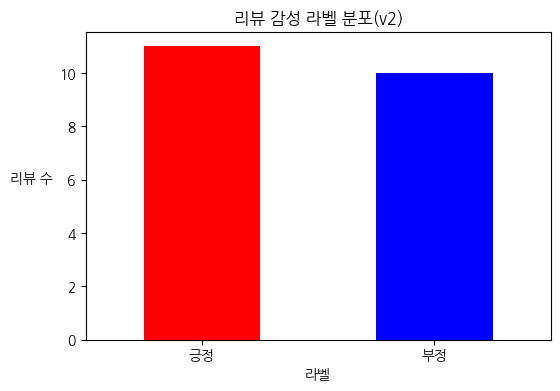

In [ ]:
counts = df['label_name'].value_counts().reindex(['긍정', '부정'])
print(counts)

print(f"counts의 타입은 {type(counts)}")

plt.figure(figsize=(6,4))
ax = counts.plot(kind='bar', color=['red', 'blue'], rot=0)
ax.set_title('리뷰 감성 라벨 분포(v2)')
ax.set_xlabel('라벨')
ax.set_ylabel('리뷰 수', rotation=0, labelpad=20)
plt.show()

In [ ]:
df['char_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.split().str.len()

display(df[['id', 'label_name', 'char_len', 'word_len', 'text']])

display(df.groupby('label_name')[['char_len', 'word_len']].agg(['count', 'mean', 'min', 'max']).round(2))

,id,label_name,char_len,word_len,text
0,1,긍정,28,5,정말 재미있어요! 배우들의 연기가 인상적이었습니다.
1,2,긍정,19,4,스토리는 평범하지만 음악이 좋네요.
2,3,부정,21,4,기대보다 지루했고 결말이 아쉬웠습니다.
3,4,긍정,26,6,영상미는 훌륭합니다. 다만 전개가 조금 느려요.
4,5,부정,20,5,다시는 보고 싶지 않은 영화예요...
5,6,긍정,25,7,가족과 함께 보기 좋은 따뜻한 작품입니다 :)
6,7,부정,24,6,배우는 좋았지만 대사가 잘 들리지 않았어요.
7,8,긍정,22,6,추천합니다! 다음 편도 꼭 보고 싶어요.
8,9,부정,24,5,별로예요. 러닝타임이 너무 길게 느껴집니다.
9,10,긍정,21,5,생각할 거리를 주는 좋은 영화였습니다.


char_len                word_len              
              count   mean min max    count  mean min max
label_name                                               
긍정               11  27.55  19  55       11  6.45   4  12
부정               10  24.00  20  31       10  5.40   4   7

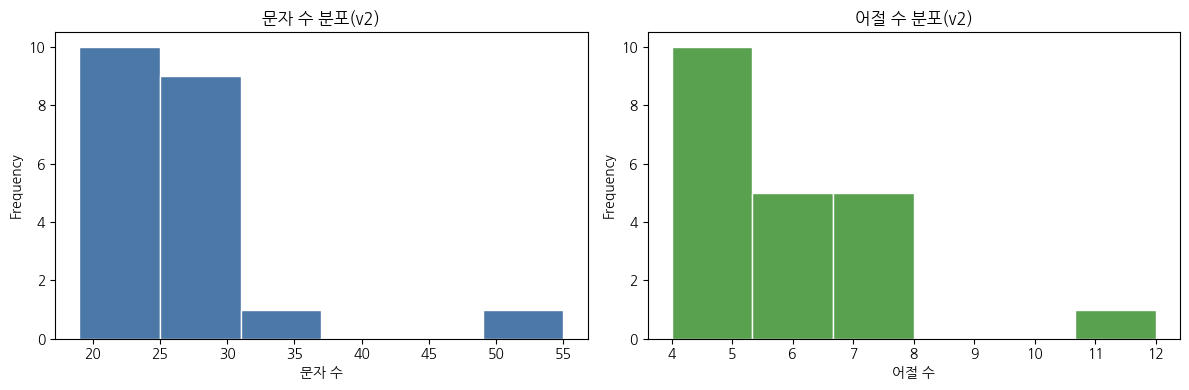

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['char_len'].plot(kind='hist', bins=6, ax=axes[0], color="#4C78A8", edgecolor='white')
axes[0].set_title('문자 수 분포(v2)')
axes[0].set_xlabel('문자 수')

df['word_len'].plot(kind='hist', bins=6, ax=axes[1], color="#59A14F", edgecolor='white')
axes[1].set_title('어절 수 분포(v2)')
axes[1].set_xlabel('어절 수')

plt.tight_layout()
plt.show()

In [ ]:
def simple_tokenize(text):
  return re.findall(r'[가-힣A-Za-z0-9]+', text.lower())

all_tokens = [
    token
    for text in df['text']
    for token in simple_tokenize(text)
]

freq = Counter(all_tokens)

print(type(freq))

print('전체 토큰 수:', len(all_tokens))
print('고유 토큰 수:', len(freq))
print('어휘 다양성:', round(len(freq) / len(all_tokens), 3))
display(pd.DataFrame(freq.most_common(20), columns=['token', 'count']))

<class 'collections.Counter'>
전체 토큰 수: 123
고유 토큰 수: 112
어휘 다양성: 0.911


,token,count
0,좋은,3
1,정말,2
2,배우들의,2
3,아쉬웠습니다,2
4,보고,2
5,싶지,2
6,함께,2
7,좋았지만,2
8,대사가,2
9,영화였습니다,2


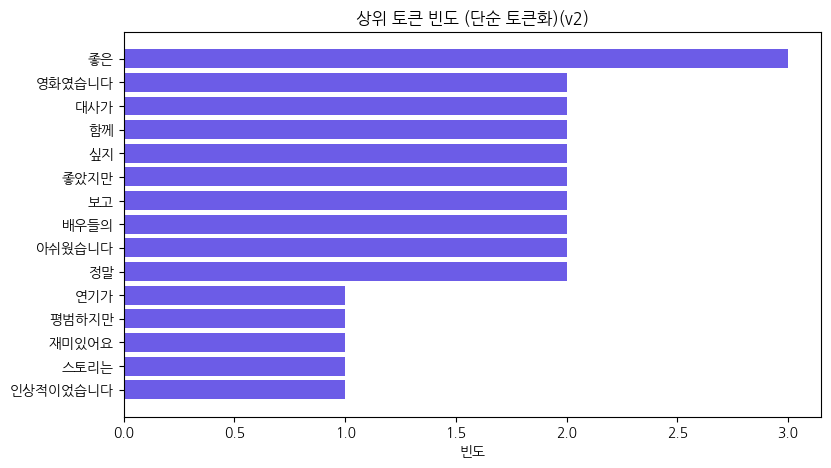

In [ ]:
freq_df = pd.DataFrame(freq.most_common(15), columns=['token', 'count'])
freq_df = freq_df.sort_values('count')

plt.figure(figsize=(9, 5))
plt.barh(freq_df['token'], freq_df['count'], color='#6C5CE7')
plt.title('상위 토큰 빈도 (단순 토큰화)(v2)')
plt.xlabel('빈도')
plt.show()

In [ ]:
# @title 2. quality_flags에 반복 문자('ㅋㅋㅋㅋ', '!!!!', '...' 등) 탐지 규칙 추가
def quality_flags_v2(text):
  flags = []
  if not isinstance(text, str) or not text.strip():
    flags.append('빈 텍스트')
  if '�' in text:
    flags.append('인코딩 깨짐 의심')

  if re.search(r'[\u1100-\u11FF]', text): # 자모가 쪼개졌을 때의 유니코드 코드값 범위 안쪽에 해당하는 자모가 text에 있는 경우
  # if re.compile(r'[\u1100-\u11FF]').search(text): # 정규표현식 문자열을 미리 패턴 객체로 변환하여, 빠르게 처리하도록 하는 함수. .search(), .findall() 등의 메서드 직접 호출 가능
    flags.append('자모 분리 현상 발생')

  if re.search(r'https?://\S+|www\.\S+', text):
    flags.append('URL 포함')
  if re.search(r'[\w.+-]+@[\w-]+\.[\w.-]+', text):
    flags.append('이메일 포함 가능성')
  if re.search(r'\d{2,3}[-]?\d{3,4}[-]?\d{4}', text):
    flags.append('전화번호 포함 가능성')

  if re.search(r'([\S])\1{2,}', text): # \S -> 공백 이외의 모든 문자. 이를 괄호로 감싸면 정규표현식 엔진이 해당 문자를 메모리에 기억하고, 1번 그룹으로 명칭
    flags.append('반복문자 포함 가능성') # \1은 역참조로, 1번 그룹에서 기억한 해당 문자가 바로 이어서 나와야 한다는 것. {2,}는 앞의 요소가 2번 이상 연속으로 나와야 함을 의미. 결국 동일한 문자가 최소 3번 연속으로 나오는 것을 찾을 수 있음.
  return ', '.join(flags) if flags else '이상 없음'

df['quality_check'] = df['text'].apply(quality_flags_v2)
display(df[['id', 'text', 'quality_check']])

,id,text,quality_check
0,1,정말 재미있어요! 배우들의 연기가 인상적이었습니다.,이상 없음
1,2,스토리는 평범하지만 음악이 좋네요.,이상 없음
2,3,기대보다 지루했고 결말이 아쉬웠습니다.,이상 없음
3,4,영상미는 훌륭합니다. 다만 전개가 조금 느려요.,이상 없음
4,5,다시는 보고 싶지 않은 영화예요...,반복문자 포함 가능성
5,6,가족과 함께 보기 좋은 따뜻한 작품입니다 :),이상 없음
6,7,배우는 좋았지만 대사가 잘 들리지 않았어요.,이상 없음
7,8,추천합니다! 다음 편도 꼭 보고 싶어요.,이상 없음
8,9,별로예요. 러닝타임이 너무 길게 느껴집니다.,이상 없음
9,10,생각할 거리를 주는 좋은 영화였습니다.,이상 없음


In [ ]:
!pip -q install -U kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 11.7 MB/s eta 0:00:00


In [ ]:
# @title 3. 공백 토큰화의 한계와 형태소 분석기의 보완 예상

# 1) 공백 토큰화의 한계
sample = '아버지가방에들어가신다.'
print('원문:', sample)

regex_tokens = re.findall(r'[가-힣A-Za-z0-9]+', sample)
print('간단 정규표현식:', regex_tokens) # 띄어쓰기 오류가 있는 경우, 공백으로 자르면 의미적 왜곡을 잡을 수 없다.

# 2) 형태소 분석기의 보완 예상
from kiwipiepy import Kiwi

kiwi = Kiwi()
print('\n[형태소 분석 결과]')
for token in kiwi.tokenize(sample):
  print(f"{token.form:10s} | {token.tag}")

원문: 아버지가방에들어가신다.
간단 정규표현식: ['아버지가방에들어가신다']

[형태소 분석 결과]
아버지        | NNG
가          | JKS
방          | NNG
에          | JKB
들어가        | VV
시          | EP
ᆫ다         | EF
.          | SF


In [ ]:
# @title 4. 외부 데이터셋 사용 시 README 작성

# 이와 같은 문서화가 중요합니다.
readme_content = """# 데이터셋 정보 (Data Card)

## 1. 출처 (Source)
- 데이터셋 이름: 영화 리뷰 감성 분석 실습 데이터
- 구성: 자체 작성 예시 리뷰(reviews 리스트, 21건) + 외부 데이터셋 병합 시 하단에 출처 추가 기입
- 원본 제공처: (외부 데이터셋 사용 시 예: 네이버 영화 리뷰 공개 코퍼스 / AI Hub)
- 원본 URL: (외부 데이터셋 사용 시 링크 기입)
- 수집 방식: 자체 작성 / (외부 데이터셋 사용 시: Open API 활용 / 공개 데이터셋 다운로드 등)
- 수집(작성) 일자: 2026-08-25 ~ 2026-09-18

## 2. 라이선스 (License)
- 자체 작성 데이터: 교육 목적 실습용, 재배포 시 출처 표기 요망
- 외부 데이터셋 병합 시: 라이선스 종류(예: CC BY 4.0), 상업적 이용 가능 여부, 재배포 조건을 원본 제공처 약관에 따라 명시

## 3. 개인정보 처리 방침 (Privacy Policy)
- PII 포함 여부: 없음 (실명, 연락처, 주소 등 개인식별정보 미포함 확인 완료)
- 비식별화 처리 여부: 해당 없음 (원천적으로 PII 미포함)
- 향후 외부 크롤링 데이터 병합 시: 정규표현식 기반 전화번호·이메일 탐지 및 마스킹 처리 예정

## 4. 데이터 구성
- 총 건수: 21건 (label 1=긍정 11건, label 0=부정 10건)
- 컬럼 설명: id(리뷰 고유번호), text(리뷰 본문), label(감성 라벨, 1=긍정/0=부정), date(작성일자)
- quality_flags: 결측(empty_text), 반복문자(repeated_char), 특수문자 과다(too_many_special_chars), 자소 분리 현상 탐지 결과

## 5. 알려진 한계 (Known Limitations)
- 표본 수가 21건으로 매우 적어 통계적 일반화에 한계가 있음
- 공백 토큰화 기준 분석 시 조사/어미로 인한 토큰 분산 문제 존재 (형태소 분석 적용 권장)
- 반복 문자 탐지 규칙은 감정 표현(ㅠㅠ, ㅋㅋ 등)을 노이즈로 오탐할 가능성 있음
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README.md 파일이 생성되었습니다.")
print(readme_content)

README.md 파일이 생성되었습니다.
# 데이터셋 정보 (Data Card)

## 1. 출처 (Source)
- 데이터셋 이름: 영화 리뷰 감성 분석 실습 데이터
- 구성: 자체 작성 예시 리뷰(reviews 리스트, 21건) + 외부 데이터셋 병합 시 하단에 출처 추가 기입
- 원본 제공처: (외부 데이터셋 사용 시 예: 네이버 영화 리뷰 공개 코퍼스 / AI Hub)
- 원본 URL: (외부 데이터셋 사용 시 링크 기입)
- 수집 방식: 자체 작성 / (외부 데이터셋 사용 시: Open API 활용 / 공개 데이터셋 다운로드 등)
- 수집(작성) 일자: 2026-08-25 ~ 2026-09-18

## 2. 라이선스 (License)
- 자체 작성 데이터: 교육 목적 실습용, 재배포 시 출처 표기 요망
- 외부 데이터셋 병합 시: 라이선스 종류(예: CC BY 4.0), 상업적 이용 가능 여부, 재배포 조건을 원본 제공처 약관에 따라 명시

## 3. 개인정보 처리 방침 (Privacy Policy)
- PII 포함 여부: 없음 (실명, 연락처, 주소 등 개인식별정보 미포함 확인 완료)
- 비식별화 처리 여부: 해당 없음 (원천적으로 PII 미포함)
- 향후 외부 크롤링 데이터 병합 시: 정규표현식 기반 전화번호·이메일 탐지 및 마스킹 처리 예정

## 4. 데이터 구성
- 총 건수: 21건 (label 1=긍정 11건, label 0=부정 10건)
- 컬럼 설명: id(리뷰 고유번호), text(리뷰 본문), label(감성 라벨, 1=긍정/0=부정), date(작성일자)
- quality_flags: 결측(empty_text), 반복문자(repeated_char), 특수문자 과다(too_many_special_chars), 자소 분리 현상 탐지 결과

## 5. 알려진 한계 (Known Limitations)
- 표본 수가 21건으로 매우 적어 통계적 일반화에 한계가 있음
- 공백 토큰화 기준 분석 시 조사/어미로 인한 토큰 분산 문제 존재 (형태